# 04C - xAPI Benchmark Model Hyperparameter Tuning

This notebook performs dedicated hyperparameter tuning for the **xAPI-Edu-Data benchmark model**.

The xAPI model is an **optional benchmark / research model** for the Smart Learning System. It supports the ML experimentation section, while the core project-aligned models remain:

- Pass/Fail Risk Model
- Sri Lankan A/L Commerce Risk Model

## 1. Notebook Objectives

This notebook will:

- Load the processed xAPI encoded dataset from `02_Data_Preprocessing.ipynb`.
- Use `Class` as the readable target label (`L`, `M`, `H`).
- Exclude `Class_Encoded` from model features to prevent target leakage.
- Compare baseline Logistic Regression, Decision Tree and Random Forest models.
- Tune candidate models with `GridSearchCV`.
- Select the best tuned xAPI benchmark model using balanced multi-class metrics.
- Export tuning results, best parameters, classification reports and confusion matrices.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

## 2. Resolve Project Paths

In [2]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
TUNING_DIR = ML_ROOT / "outputs" / "tuning"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

XAPI_DATASET = PROCESSED_DIR / "xapi_encoded.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("xAPI dataset:", XAPI_DATASET)
print("Tuning directory:", TUNING_DIR)
print("Figures directory:", FIGURES_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
xAPI dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/xapi_encoded.csv
Tuning directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Metadata and Define xAPI Setup

In [3]:
if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text())
else:
    metadata = {}

xapi_features_from_metadata = metadata.get("xapi_encoded_feature_names", [])
xapi_target = metadata.get("xapi_target", "Class")
xapi_target_encoding = metadata.get("xapi_target_encoding", {"L": 0, "M": 1, "H": 2})
leakage_columns = ["Class_Encoded"]

print("xAPI target:", xapi_target)
print("Target encoding:", xapi_target_encoding)
print("Metadata feature count:", len(xapi_features_from_metadata))
print("Data leakage note:", metadata.get("data_leakage_prevention", "Pipeline transformations are fitted on training data only."))

xAPI target: Class
Target encoding: {'L': 0, 'M': 1, 'H': 2}
Metadata feature count: 72
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

`Class_Encoded` is an encoded version of the target. It is useful for metadata/documentation, but it must not be included in the feature matrix.

This notebook fits imputation and scaling only inside scikit-learn pipelines and `GridSearchCV` folds.

## 5. Load xAPI Encoded Dataset

In [4]:
if not XAPI_DATASET.exists():
    raise FileNotFoundError(f"Missing dataset: {XAPI_DATASET}. Run 02_Data_Preprocessing.ipynb first.")

xapi_df = pd.read_csv(XAPI_DATASET)
print("Dataset shape:", xapi_df.shape)
display(xapi_df.head())

Dataset shape: (478, 74)


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,PlaceofBirth_Egypt,PlaceofBirth_Iran,PlaceofBirth_Iraq,PlaceofBirth_Jordan,PlaceofBirth_KuwaIT,PlaceofBirth_Lybia,PlaceofBirth_Morocco,PlaceofBirth_Palestine,PlaceofBirth_SaudiArabia,PlaceofBirth_Syria,PlaceofBirth_Tunis,PlaceofBirth_USA,PlaceofBirth_lebanon,PlaceofBirth_venzuela,StageID_HighSchool,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-02,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,SectionID_A,SectionID_B,SectionID_C,Topic_Arabic,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7,Class,Class_Encoded
0,15,16,2,20,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
1,20,20,3,25,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
2,10,7,0,30,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
3,30,25,5,35,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
4,40,50,12,50,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,M,1


## 6. Validate Columns and Data Types

In [5]:
if xapi_target not in xapi_df.columns:
    raise ValueError(f"Missing xAPI target column: {xapi_target}")

if xapi_features_from_metadata:
    missing_features = [column for column in xapi_features_from_metadata if column not in xapi_df.columns]
    if missing_features:
        raise ValueError(f"Missing xAPI feature columns: {missing_features[:10]}")
else:
    xapi_features_from_metadata = [column for column in xapi_df.columns if column not in [xapi_target, *leakage_columns]]

available_leakage_columns = [column for column in leakage_columns if column in xapi_df.columns]
xapi_features = [column for column in xapi_features_from_metadata if column not in leakage_columns and column != xapi_target]

print("Target column available:", xapi_target)
print("Leakage-prone columns present but excluded:", available_leakage_columns)
print("Final feature count:", len(xapi_features))
display(pd.DataFrame({"Data Type": xapi_df[xapi_features + [xapi_target]].dtypes.astype(str)}).head(25))

Target column available: Class
Leakage-prone columns present but excluded: ['Class_Encoded']
Final feature count: 72


,Data Type
raisedhands,int64
VisITedResources,int64
AnnouncementsView,int64
Discussion,int64
gender_F,int64
gender_M,int64
NationalITy_Egypt,int64
NationalITy_Iran,int64
NationalITy_Iraq,int64
NationalITy_Jordan,int64


## 7. Class Distribution

Target values:

- `L` = Low performance
- `M` = Medium performance
- `H` = High performance

In [6]:
target_counts = xapi_df[xapi_target].value_counts()
target_percentages = xapi_df[xapi_target].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2),
})

display(class_summary)

available_classes = sorted(xapi_df[xapi_target].unique().tolist())
print("Available classes:", available_classes)

class_summary_path = TUNING_DIR / "xapi_tuning_class_distribution.csv"
class_summary.to_csv(class_summary_path)
print("Saved:", class_summary_path)

,Count,Percentage
Class,,
M,211,44.14
H,142,29.71
L,125,26.15


Available classes: ['H', 'L', 'M']
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_tuning_class_distribution.csv


## 8. Feature and Target Separation

In [7]:
X = xapi_df[xapi_features].copy()
y = xapi_df[xapi_target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (478, 72)
y shape: (478,)


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,PlaceofBirth_Egypt,PlaceofBirth_Iran,PlaceofBirth_Iraq,PlaceofBirth_Jordan,PlaceofBirth_KuwaIT,PlaceofBirth_Lybia,PlaceofBirth_Morocco,PlaceofBirth_Palestine,PlaceofBirth_SaudiArabia,PlaceofBirth_Syria,PlaceofBirth_Tunis,PlaceofBirth_USA,PlaceofBirth_lebanon,PlaceofBirth_venzuela,StageID_HighSchool,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-02,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,SectionID_A,SectionID_B,SectionID_C,Topic_Arabic,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,15,16,2,20,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1
1,20,20,3,25,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1
2,10,7,0,30,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0
3,30,25,5,35,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0
4,40,50,12,50,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0


## 9. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Rows": [len(y_train), len(y_test)],
})

for label in available_classes:
    split_summary[label] = [int((y_train == label).sum()), int((y_test == label).sum())]

display(split_summary)

,Split,Rows,H,L,M
0,Training,382,113,100,169
1,Testing,96,29,25,42


## 10. Helper Functions

In [9]:
def calculate_multiclass_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def make_baseline_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=8)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
    }


def make_tuning_grids():
    return {
        "Logistic Regression": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__C": [0.01, 0.1, 1.0, 10.0],
                "model__solver": ["lbfgs", "liblinear"],
            },
        ),
        "Decision Tree": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__criterion": ["gini", "entropy"],
                "model__max_depth": [3, 5, 8, 12, None],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
        ),
        "Random Forest": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [None, 8, 12],
                "model__min_samples_split": [2, 5],
                "model__min_samples_leaf": [1, 2],
                "model__max_features": ["sqrt", "log2"],
            },
        ),
    }


def save_confusion_matrix(y_true, y_pred, labels, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    display_obj.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))

## 11. Baseline Model Evaluation

In [10]:
baseline_rows = []
baseline_models = make_baseline_models()
baseline_predictions = {}

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_predictions[model_name] = y_pred
    baseline_rows.append({
        "Model": model_name,
        "Version": "Baseline",
        **calculate_multiclass_metrics(y_test, y_pred),
    })

baseline_df = pd.DataFrame(baseline_rows).round(4)
display(baseline_df)

baseline_path = TUNING_DIR / "xapi_baseline_scores.csv"
baseline_df.to_csv(baseline_path, index=False)
print("Saved:", baseline_path)

,Model,Version,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Baseline,0.7708,0.7950,0.7701,0.7950,0.7765,0.7672
1,Decision Tree,Baseline,0.6562,0.6738,0.6596,0.6738,0.6639,0.6524
2,Random Forest,Baseline,0.7917,0.7966,0.8013,0.7966,0.7979,0.7911


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_baseline_scores.csv


## 12. Hyperparameter Search Space

In [11]:
tuning_grids = make_tuning_grids()

for model_name, (_, param_grid) in tuning_grids.items():
    combinations = 1
    for values in param_grid.values():
        combinations *= len(values)
    print(f"{model_name}: {combinations} parameter combinations")

Logistic Regression: 8 parameter combinations
Decision Tree: 90 parameter combinations
Random Forest: 72 parameter combinations


## 13. Run GridSearchCV Tuning

The scoring metric is `balanced_accuracy`, with Macro F1 used later as supporting evidence.

In [12]:
minimum_class_count = int(y_train.value_counts().min())
n_splits = min(5, minimum_class_count)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

tuning_rows = []
tuned_models = {}
tuned_predictions = {}
all_cv_results = []

for model_name, (pipeline, param_grid) in tuning_grids.items():
    print("Running GridSearchCV:", model_name)
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=None,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_
    y_pred = tuned_model.predict(X_test)

    tuned_models[model_name] = tuned_model
    tuned_predictions[model_name] = y_pred

    tuning_rows.append({
        "Model": model_name,
        "Version": "Tuned",
        "Best CV Balanced Accuracy": search.best_score_,
        "Best Parameters": json.dumps(search.best_params_),
        "CV Folds": n_splits,
        **calculate_multiclass_metrics(y_test, y_pred),
    })

    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_df["Model"] = model_name
    all_cv_results.append(cv_results_df)

tuning_df = pd.DataFrame(tuning_rows).round(4)
display(tuning_df)

tuning_results_path = TUNING_DIR / "xapi_tuning_results.csv"
tuning_df.to_csv(tuning_results_path, index=False)
print("Saved:", tuning_results_path)

cv_results_path = TUNING_DIR / "xapi_tuning_cv_results.csv"
pd.concat(all_cv_results, ignore_index=True).to_csv(cv_results_path, index=False)
print("Saved:", cv_results_path)

Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Tuned,0.7589,"{""model__C"": 0.01, ""model__solver"": ""lbfgs""}",5,0.6979,0.7413,0.7041,0.7413,0.7021,0.6835
1,Decision Tree,Tuned,0.7489,"{""model__criterion"": ""entropy"", ""model__max_de...",5,0.6771,0.7022,0.6794,0.7022,0.6878,0.6727
2,Random Forest,Tuned,0.8026,"{""model__max_depth"": 12, ""model__max_features""...",5,0.7812,0.7994,0.7812,0.7994,0.7881,0.7791


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_tuning_results.csv
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_tuning_cv_results.csv


## 14. Baseline vs Tuned Comparison

In [13]:
comparison_df = pd.concat([baseline_df, tuning_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(
    by=["Balanced Accuracy", "Macro F1 Score", "Accuracy", "Weighted F1 Score"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

comparison_path = TUNING_DIR / "xapi_baseline_vs_tuned_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,Model,Version,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,Best CV Balanced Accuracy,Best Parameters,CV Folds
0,Random Forest,Tuned,0.7812,0.7994,0.7812,0.7994,0.7881,0.7791,0.8026,"{""model__max_depth"": 12, ""model__max_features""...",5.0
1,Random Forest,Baseline,0.7917,0.7966,0.8013,0.7966,0.7979,0.7911,NaN,NaN,NaN
2,Logistic Regression,Baseline,0.7708,0.7950,0.7701,0.7950,0.7765,0.7672,NaN,NaN,NaN
3,Logistic Regression,Tuned,0.6979,0.7413,0.7041,0.7413,0.7021,0.6835,0.7589,"{""model__C"": 0.01, ""model__solver"": ""lbfgs""}",5.0
4,Decision Tree,Tuned,0.6771,0.7022,0.6794,0.7022,0.6878,0.6727,0.7489,"{""model__criterion"": ""entropy"", ""model__max_de...",5.0
5,Decision Tree,Baseline,0.6562,0.6738,0.6596,0.6738,0.6639,0.6524,NaN,NaN,NaN


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_baseline_vs_tuned_comparison.csv


## 15. Select Best Tuned Model

In [14]:
tuned_only = tuning_df.sort_values(
    by=["Balanced Accuracy", "Macro F1 Score", "Accuracy", "Best CV Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

best_model_name = tuned_only.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
best_predictions = tuned_predictions[best_model_name]
best_params = json.loads(tuned_only.iloc[0]["Best Parameters"])

print("Best tuned xAPI Benchmark model:", best_model_name)
print("Best parameters:", best_params)
display(tuned_only.head(1))

Best tuned xAPI Benchmark model: Random Forest
Best parameters: {'model__max_depth': 12, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Random Forest,Tuned,0.8026,"{""model__max_depth"": 12, ""model__max_features""...",5,0.7812,0.7994,0.7812,0.7994,0.7881,0.7791


## 16. Best Tuned Model Classification Report

In [15]:
report_text = classification_report(y_test, best_predictions, zero_division=0)
print(report_text)

report_dict = classification_report(y_test, best_predictions, output_dict=True, zero_division=0)
report_path = TUNING_DIR / "xapi_best_tuned_classification_report.json"
report_path.write_text(json.dumps(report_dict, indent=2))
print("Saved:", report_path)

              precision    recall  f1-score   support

           H       0.77      0.83      0.80        29
           L       0.79      0.88      0.83        25
           M       0.78      0.69      0.73        42

    accuracy                           0.78        96
   macro avg       0.78      0.80      0.79        96
weighted avg       0.78      0.78      0.78        96

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_best_tuned_classification_report.json


## 17. Best Tuned Model Confusion Matrix

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_best_tuned_confusion_matrix.png


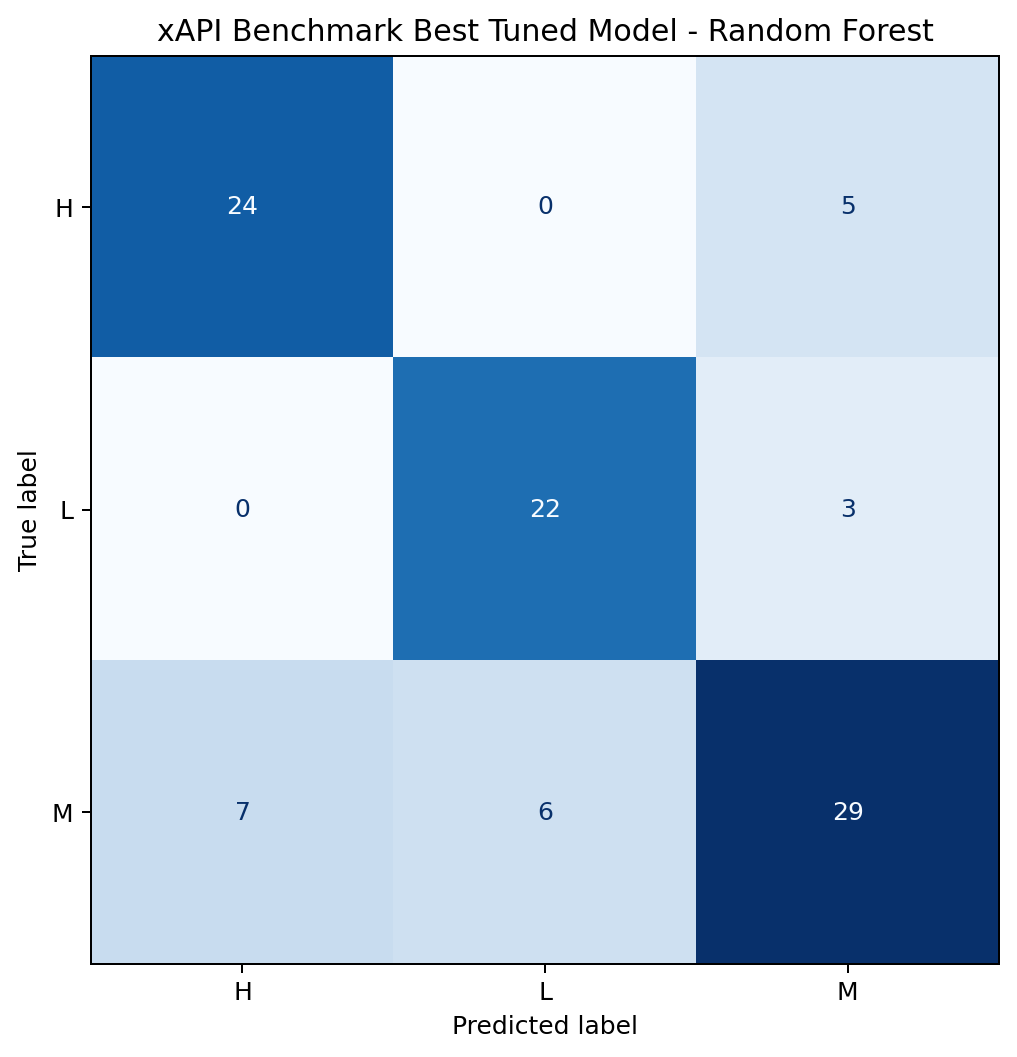

In [16]:
best_cm_path = FIGURES_DIR / "xapi_best_tuned_confusion_matrix.png"
save_confusion_matrix(
    y_test,
    best_predictions,
    available_classes,
    f"xAPI Benchmark Best Tuned Model - {best_model_name}",
    best_cm_path,
)

## 18. Confusion Matrices for All Tuned Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_tuned_logistic_regression_confusion_matrix.png


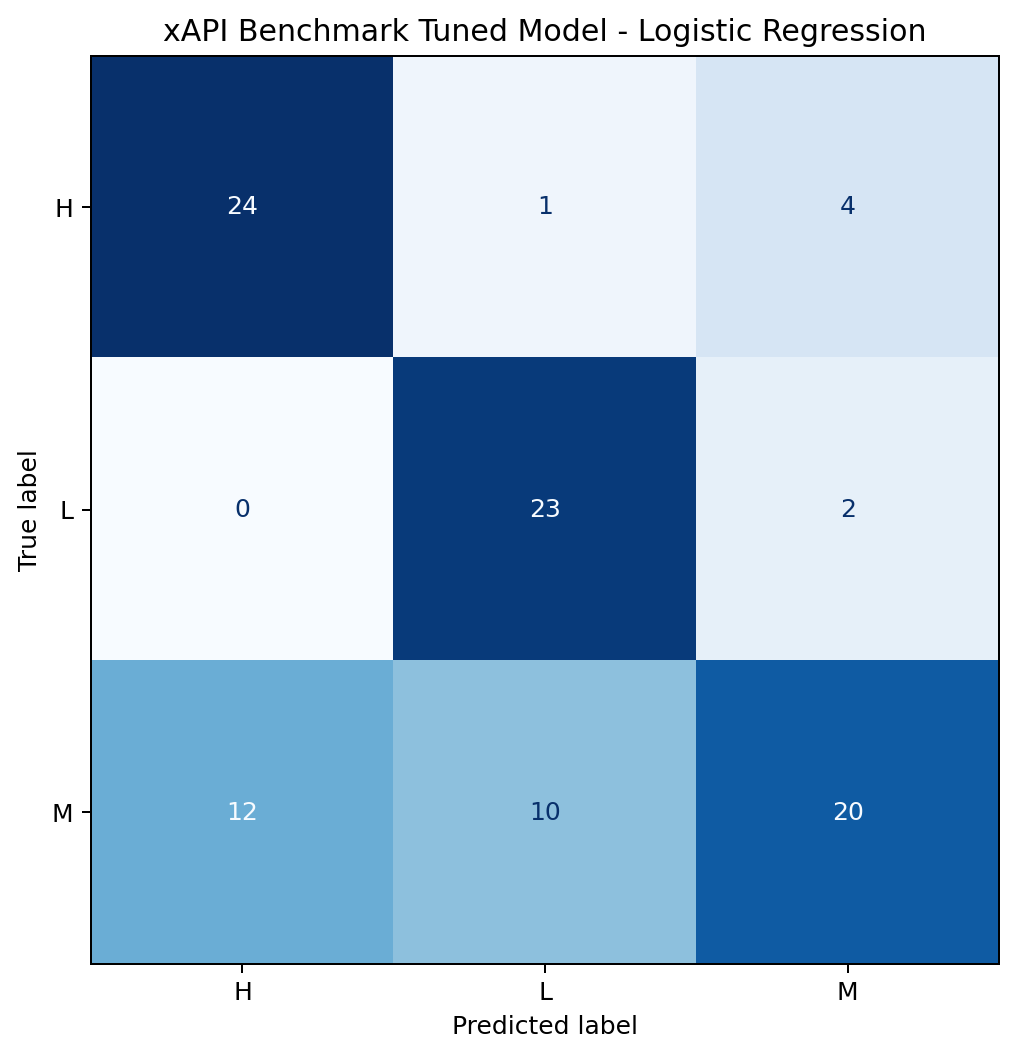

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_tuned_decision_tree_confusion_matrix.png


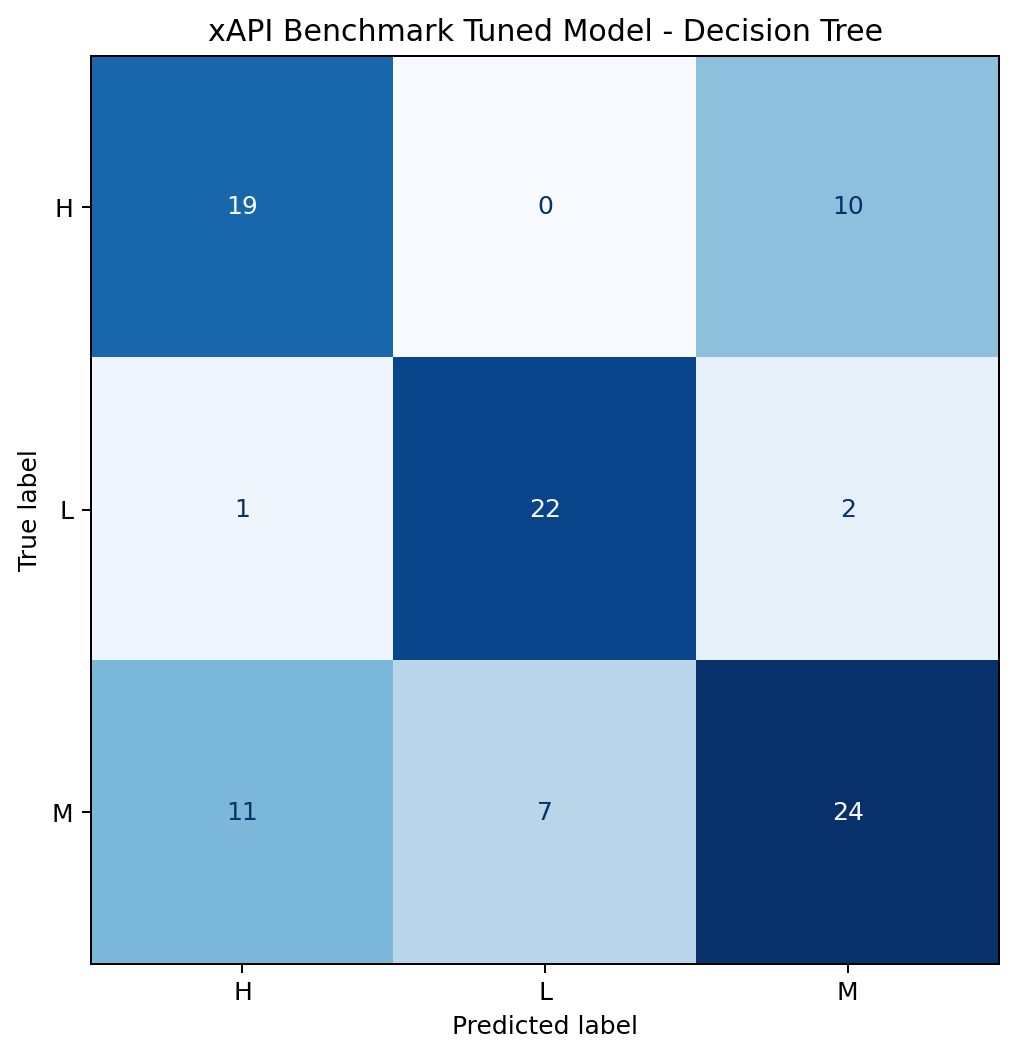

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_tuned_random_forest_confusion_matrix.png


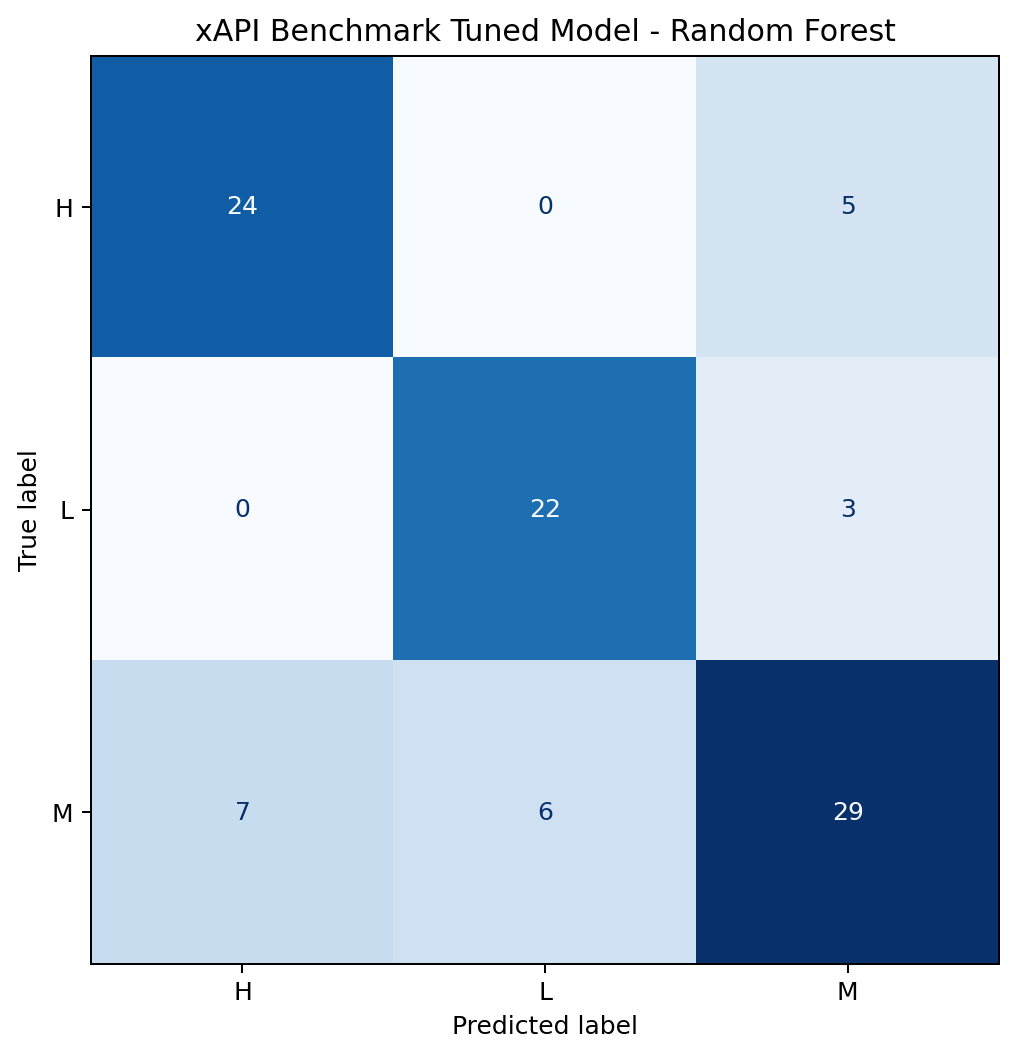

In [17]:
for model_name, y_pred in tuned_predictions.items():
    safe_name = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"xapi_tuned_{safe_name}_confusion_matrix.png"
    save_confusion_matrix(
        y_test,
        y_pred,
        available_classes,
        f"xAPI Benchmark Tuned Model - {model_name}",
        output_path,
    )

## 19. Feature Importance / Coefficient Analysis

In [18]:
importance_rows = []

for model_name, pipeline in tuned_models.items():
    model_step = pipeline.named_steps["model"]
    if hasattr(model_step, "feature_importances_"):
        values = model_step.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(model_step, "coef_"):
        values = np.mean(np.abs(model_step.coef_), axis=0)
        importance_type = "mean_absolute_coefficient"
    else:
        continue

    for feature, value in zip(xapi_features, values):
        importance_rows.append({
            "Model": model_name,
            "Importance Type": importance_type,
            "Feature": feature,
            "Value": float(value),
        })

importance_df = pd.DataFrame(importance_rows).sort_values(["Model", "Value"], ascending=[True, False])
display(importance_df.groupby("Model").head(10).round(4))

importance_path = TUNING_DIR / "xapi_tuned_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path)

,Model,Importance Type,Feature,Value
142,Decision Tree,feature_importance,StudentAbsenceDays_Above-7,0.3415
72,Decision Tree,feature_importance,raisedhands,0.1831
73,Decision Tree,feature_importance,VisITedResources,0.1703
75,Decision Tree,feature_importance,Discussion,0.0444
74,Decision Tree,feature_importance,AnnouncementsView,0.0364
141,Decision Tree,feature_importance,ParentschoolSatisfaction_Good,0.0361
137,Decision Tree,feature_importance,Relation_Mum,0.0245
110,Decision Tree,feature_importance,GradeID_G-04,0.0184
82,Decision Tree,feature_importance,NationalITy_KW,0.0183
77,Decision Tree,feature_importance,gender_M,0.0183


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_tuned_feature_importance.csv


## 20. Best Parameter Table

In [19]:
best_parameter_rows = [
    {"Model": best_model_name, "Parameter": parameter, "Value": value}
    for parameter, value in best_params.items()
]

best_parameters_df = pd.DataFrame(best_parameter_rows)
display(best_parameters_df)

best_parameters_path = TUNING_DIR / "xapi_best_tuned_parameters.csv"
best_parameters_df.to_csv(best_parameters_path, index=False)
print("Saved:", best_parameters_path)

,Model,Parameter,Value
0,Random Forest,model__max_depth,12
1,Random Forest,model__max_features,log2
2,Random Forest,model__min_samples_leaf,2
3,Random Forest,model__min_samples_split,2
4,Random Forest,model__n_estimators,300


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_best_tuned_parameters.csv


## 21. Documentation Summary

In [20]:
summary = {
    "notebook": "04C_xAPI_Tuning.ipynb",
    "model_purpose": "Optional xAPI-Edu-Data benchmark performance classification",
    "dataset": str(XAPI_DATASET),
    "rows": int(xapi_df.shape[0]),
    "feature_count": int(len(xapi_features)),
    "target": xapi_target,
    "target_encoding": xapi_target_encoding,
    "available_classes": available_classes,
    "excluded_leakage_columns": available_leakage_columns,
    "candidate_models": list(tuning_grids.keys()),
    "best_tuned_model": best_model_name,
    "best_parameters": best_params,
    "selection_metric": "Balanced Accuracy with Macro F1 and Accuracy as supporting metrics",
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Class_Encoded is excluded and pipeline transformations are fitted inside training folds only.",
    "tuning_results_file": str(tuning_results_path),
    "comparison_file": str(comparison_path),
    "classification_report_file": str(report_path),
    "confusion_matrix_file": str(best_cm_path),
}

summary_path = TUNING_DIR / "xapi_tuning_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print("Saved:", summary_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/xapi_tuning_summary.json


## 23. Final Conclusion

This notebook completed dedicated hyperparameter tuning for the optional xAPI benchmark model. The notebook used the encoded xAPI feature set, kept the target as readable labels (`L`, `M`, `H`) and explicitly excluded `Class_Encoded` to prevent leakage.

The tuned model outputs can be used in project documentation as benchmark/research evidence. For production project functionality, the Pass/Fail and Commerce Risk models remain the primary models.